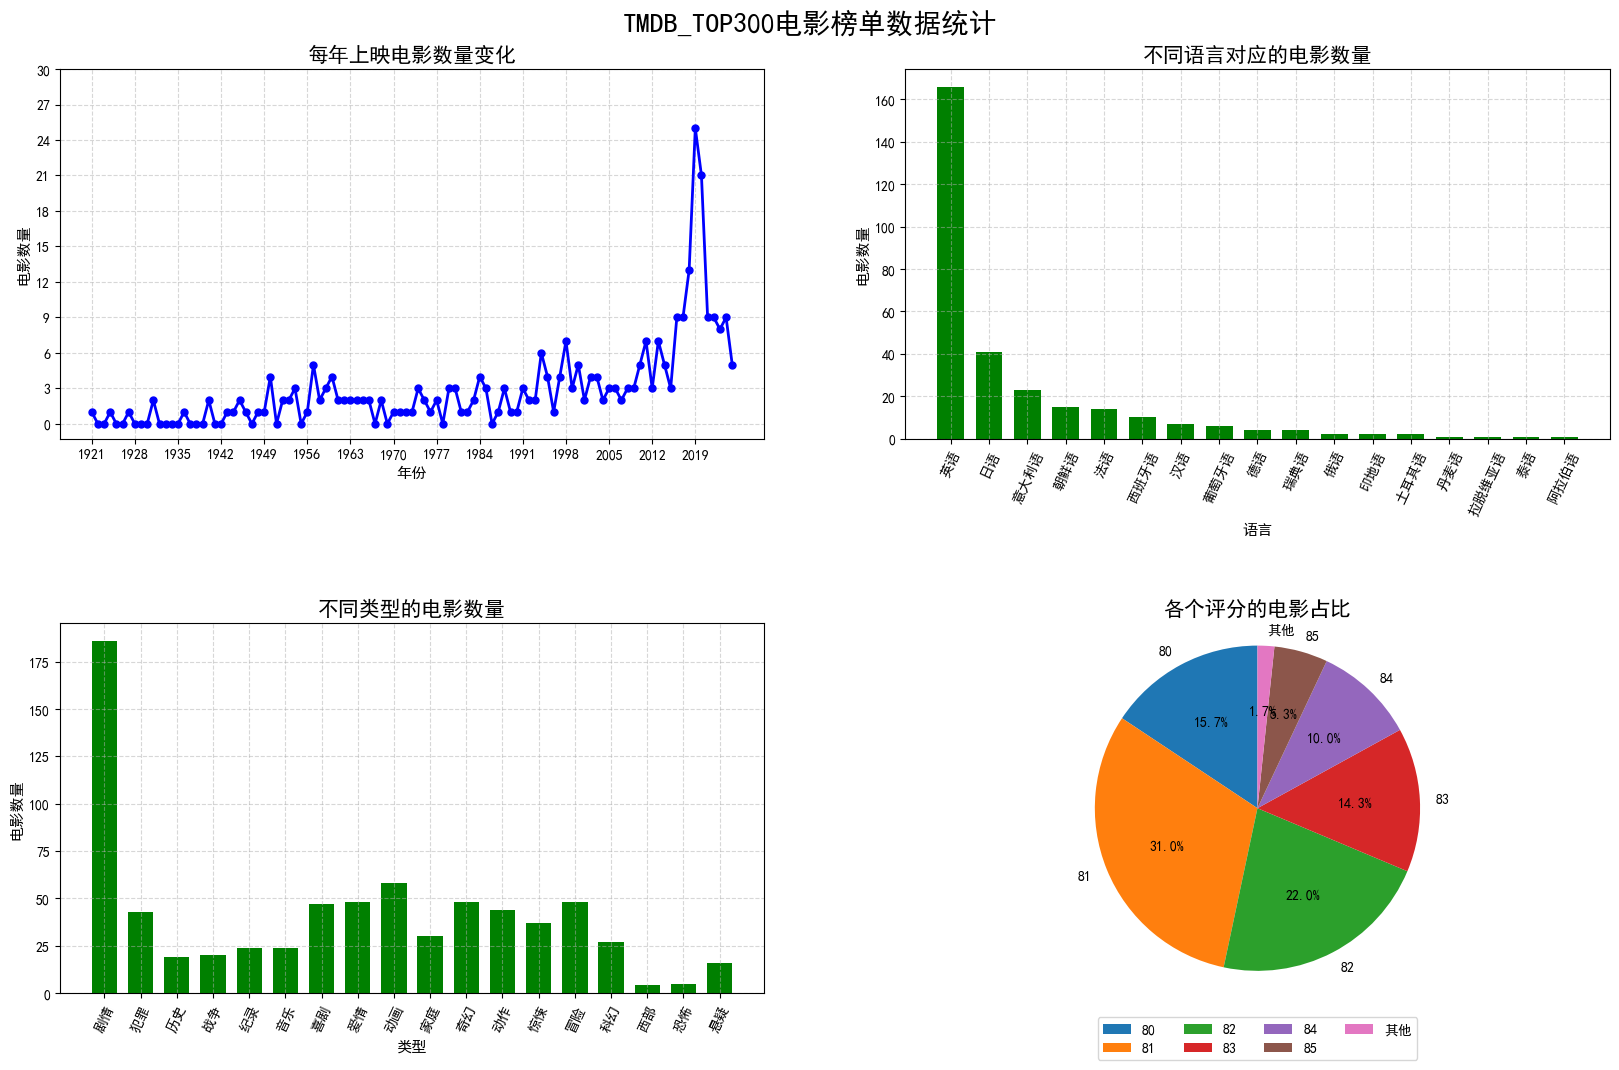

In [92]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.axes import Axes
from pydeck.data_utils.viewport_helpers import bbox_to_zoom_level

# 展示中文
plt.rcParams['font.sans-serif'] = ['SimHei']

# 创建子图(2行2列)--4张图
fig, axs = plt.subplots(2, 2, figsize=(20, 12), dpi = 100)   # 元组解包形式
# 调整子图布局
plt.subplots_adjust(hspace=0.5)  # hspace 控制垂直间距，值越大间距越大

# 总体标题
fig.suptitle('TMDB_TOP300电影榜单数据统计', fontsize=20, x = 0.5, y = 0.93)  # x 是标题的x坐标，y是标题的y坐标

# 获取子图
ax1:Axes = axs[0, 0]
ax2:Axes = axs[0, 1]
ax3:Axes = axs[1, 0]
ax4:Axes = axs[1, 1]


# 加载数据
# int64: 64位整型-->不支持空值(NAN or NA)
# float64: 64位浮点型-->支持空值
# Int64: 64位整型-->支持空值
data = pd.read_csv('data/movies.csv', usecols = ['电影名', '年份', '上映时间', '类型', '时长', '评分', '语言'], dtype ={'年份':'Int64'})  # 年份有缺失值


# 1.统计TOP300的电影中，每一年上映的电影的数量变化（折线图）

# 1.1缺失值和异常值的处理
data.isnull().sum()   # 统计缺失值 false: 0  true: 1
data['年份'] = data['年份'].fillna(data['上映时间'].str[:4])

# 1.2 分组操作
year_count = data.groupby('年份')['年份'].count()

# 1.3 组装数据
# 组装x轴数据
min_year = year_count.index.min()
max_year = year_count.index.max()
x = [i for i in range(min_year, max_year + 1)]   # 列表推导式

# 组装y轴数据
y = [int(year_count.get(i, 0)) for i in x]  # get(key, default) 获取key对应的值，如果key不存在，则返回default

# 1.4 绘制折线图
ax1.plot(x, y, color = 'b', linewidth = 2, linestyle = '-', marker = 'o', markersize = 5)
ax1.set_title('每年上映电影数量变化', fontsize = 15)  # 标题
ax1.set_xlabel('年份', fontsize = 11)  # x轴标签
ax1.set_ylabel('电影数量', fontsize = 11)  # y轴标签
ax1.set_xticks(x[::7])  # 设置x轴刻度
y_ticks = [i for i in range(0, 31, 3)]   # y轴刻度
ax1.set_yticks(y_ticks)   # 设置y轴刻度
ax1.grid(linestyle = '--', alpha = 0.5)   # 添加网格



# 统计不同语言对应的电影数量(柱状图)

# 2.1 获取不同语言对应的电影数量
language_count = data.groupby('语言')['语言'].count().sort_values(ascending= False)  # 根据值倒序排序

# 2.2 绘制柱状图
x_language = language_count.index.tolist()  # tolist() 转换为列表
y_language = language_count.values.tolist()

ax2.bar(x_language, y_language, color = 'green', width = 0.7)  # 绘制柱状图
ax2.set_title('不同语言对应的电影数量', fontsize = 15)
ax2.set_xlabel('语言', fontsize = 11)  # x轴标签
ax2.set_ylabel('电影数量', fontsize = 11)  # y轴标签
ax2.grid(linestyle = '--', alpha = 0.5)   # 添加网格
ax2.tick_params(axis = 'x', rotation = 65)  # x轴标签旋转45度


# 统计对比不同类型的电影数量(柱状图))
# 3.1 获取不同类型对应的电影数量
type_count = {}   # {'剧情': 10, '动作': 20, '喜剧': 30}
for types in data['类型'].str.split(','):
    for type in types:
        if type in type_count:
            type_count[type] += 1
        else:
            type_count[type] = 1

# 3.2 绘制柱状图
x_types = list(type_count.keys())   # 类型列表
y_values = list(type_count.values())

ax3.bar(x_types, y_values, color = 'green', width = 0.7)  # 绘制柱状图
ax3.set_title('不同类型的电影数量', fontsize = 15)
ax3.set_xlabel('类型', fontsize = 11)  # x轴标签
ax3.set_ylabel('电影数量', fontsize = 11)  # y轴标签
ax3.grid(linestyle = '--', alpha = 0.5)   # 添加网格
ax3.tick_params(axis = 'x', rotation = 65)  # x轴标签旋转45度




# 统计对比各个评分的电影占比(饼状图)

# 4.1 获取各个评分对应的电影数量
score_count = data.groupby('评分')['评分'].count()

# 合并小数据比例小于2%)为其他
total_num = score_count.sum()
large_scores= score_count.loc[score_count >= total_num * 0.02]   # 大数据
small_scores = score_count.loc[score_count < total_num * 0.02]  # 小数据

if len(small_scores) > 0:
   large_scores['其他'] = small_scores.sum()


scores = large_scores.index.tolist()
values = large_scores.values.tolist()

# 4.2 绘制饼状图
ax4.pie(values, labels = scores, autopct = '%1.1f%%', startangle = 90, radius= 1.1)   # autopct: 百分比格式， '%1.1f%%' 表示保留一位小数

ax4.set_title('各个评分的电影占比', fontsize = 15)
ax4.legend(loc = 'lower center', ncol = 4, bbox_to_anchor = (0.5, -0.2))

# 保存图片
plt.savefig('data/movies_statistics.png', bbox_inches = 'tight')

plt.show()